<a href="https://colab.research.google.com/github/PietroThompson/Sprint-An-lise-de-Dados-e-Boas-Pr-ticas-MVP/blob/main/MVP_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Pietro Thompson

**Matrícula:** 4052025002312

**Dataset:**
**Jogos de futebol das top 5 ligas europeias**



# Descrição do Problema

O dataset utilizado contém informações sobre jogos das Top 5 Ligas Europeias de Futebol (Premier League, La Liga, Bundesliga, Serie A e Ligue 1) entre as temporadas de 2014 e 2020, totalizando 12.680 partidas.

Cada registro representa um jogo e inclui informações sobre gols marcados (total e primeiro tempo), probabilidades pré-jogo estimadas por modelos estatísticos, e odds de múltiplas casas de apostas (Bet365, Betway, Interwetten, Pinnacle, William Hill e VC Bet).

O objetivo principal desta análise é entender os padrões que determinam o resultado de uma partida de futebol, como a vantagem de jogar em casa, a distribuição de gols por liga e temporada, e a capacidade preditiva das probabilidades pré-jogo.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **Times que jogam em casa têm vantagem significativa, marcando mais gols e vencendo com maior frequência?**

2. **As probabilidades pré-jogo (homeProbability, drawProbability, awayProbability) têm correlação com o resultado real da partida?**

3. **Existe diferença estatística na média de gols entre as 5 ligas analisadas?**


## Tipo de Problema

Este é um problema de **classificação supervisionada**. Dado um conjunto de características (comprimento e largura da sépala, comprimento e largura da pétala), o objetivo é prever a qual das três classes (espécies de Íris) uma determinada flor pertence.

## Seleção de Dados

O dataset foi obtido e carregado diretamente a partir de um arquivo CSV. Ele contempla partidas das **Top 5 Ligas Europeias de Futebol** (Premier League, La Liga, Bundesliga, Serie A e Ligue 1). Durante o período coberto é de 2014 a 2020, com dados de **7 temporadas completas**.

Além da base de dados principal dos jogos duas bases em arquivos CSV diferentes foram utilizadas para nomear as **Liga** e **Times** das partidas listadas.

## Atributos do Dataset

O dataset contém **12.680 instâncias** e **34 atributos**, descritos abaixo:

**Identificadores:**
- **gameID** — Identificador único do jogo
- **leagueID** — Identificador da liga (1 a 5)
- **season** — Temporada (2014 a 2020)
- **date** — Data e hora do jogo
- **homeTeamID**, **awayTeamID** — Identificadores dos times

**Variáveis de Resultado:**
- **homeGoals**, **awayGoals** — Gols marcados pelo mandante e visitante
- **homeGoalsHalfTime**, **awayGoalsHalfTime** — Gols no primeiro tempo

**Probabilidades pré-jogo:**
- **homeProbability**, **drawProbability**, **awayProbability** — Probabilidades estimadas por modelo estatístico

**Odds de casas de apostas:**
- **B365H/D/A** — Bet365 (vitória casa / empate / visitante)
- **BWH/D/A** — Betway
- **IWH/D/A** — Interwetten
- **PSH/D/A**, **PSCH/D/A** — Pinnacle
- **WHH/D/A** — William Hill
- **VCH/D/A** — VC Bet


# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset dos jogos de futebol das principais ligas europeias, assim como o case auxiliares para identificar times e liga das partidas.

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# Configurações de visualização
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# URLs das bases de dados no GitHub
URL_GAMES   = 'https://raw.githubusercontent.com/PietroThompson/Sprint-An-lise-de-Dados-e-Boas-Pr-ticas-MVP/refs/heads/main/games.csv'
URL_LEAGUES = 'https://raw.githubusercontent.com/PietroThompson/Sprint-An-lise-de-Dados-e-Boas-Pr-ticas-MVP/refs/heads/main/leagues.csv'
URL_TEAMS   = 'https://raw.githubusercontent.com/PietroThompson/Sprint-An-lise-de-Dados-e-Boas-Pr-ticas-MVP/refs/heads/main/teams.csv'


In [102]:
# carregamento do dataset (aqui, ele fica disponível nesse método)
# Carregamento das três bases de dados diretamente do GitHub
df_games   = pd.read_csv(URL_GAMES)
df_leagues = pd.read_csv(URL_LEAGUES)
df_teams   = pd.read_csv(URL_TEAMS)

In [103]:
# Merge: adicionar nome da liga à base principal
df = df_games.merge(
    df_leagues[['leagueID', 'name']].rename(columns={'name': 'leagueName'}),
    on='leagueID',
    how='left'
)

# Merge: adicionar nome do time mandante
df = df.merge(
    df_teams.rename(columns={'teamID': 'homeTeamID', 'name': 'homeTeamName'}),
    on='homeTeamID',
    how='left'
)

# Merge: adicionar nome do time visitante
df = df.merge(
    df_teams.rename(columns={'teamID': 'awayTeamID', 'name': 'awayTeamName'}),
    on='awayTeamID',
    how='left'
)

In [104]:
# primeiras linhas
df.head()

,gameID,leagueID,season,date,homeTeamID,awayTeamID,homeGoals,awayGoals,homeProbability,drawProbability,...,WHA,VCH,VCD,VCA,PSCH,PSCD,PSCA,leagueName,homeTeamName,awayTeamName
0,81,1,2015,2015-08-08 15:45:00,89,82,1,0,0.2843,0.3999,...,6.00,1.67,4.00,5.75,1.64,4.07,6.04,Premier League,Manchester United,Tottenham
1,82,1,2015,2015-08-08 18:00:00,73,71,0,1,0.3574,0.3500,...,4.00,2.00,3.50,4.20,1.82,3.88,4.70,Premier League,Bournemouth,Aston Villa
2,83,1,2015,2015-08-08 18:00:00,72,90,2,2,0.2988,0.4337,...,5.00,1.73,3.90,5.40,1.75,3.76,5.44,Premier League,Everton,Watford
3,84,1,2015,2015-08-08 18:00:00,75,77,4,2,0.6422,0.2057,...,2.70,2.00,3.40,4.33,1.79,3.74,5.10,Premier League,Leicester,Sunderland
4,85,1,2015,2015-08-08 18:00:00,79,78,1,3,0.1461,0.2159,...,2.88,2.60,3.25,3.00,2.46,3.39,3.14,Premier League,Norwich,Crystal Palace


# Análise de Dados

Nesta etapa de Análise Exploratória de Dados (EDA), buscamos entender a distribuição, as relações e as características das variáveis do dataset de futebol europeu.

## Engenharia de Atributos Inicial

Antes de explorar os dados, criamos algumas variáveis derivadas que serão úteis nas análises:
- **result** — resultado do jogo (Home Win, Draw, Away Win)
- **totalGoals** — total de gols na partida
- **goalDiff** — diferença de gols (mandante - visitante)
- **leagueName** — nome da liga por extenso


In [105]:
# Criação de variáveis derivadas
df['result'] = df.apply(
    lambda r: 'Home Win' if r['homeGoals'] > r['awayGoals']
    else ('Away Win' if r['awayGoals'] > r['homeGoals'] else 'Draw'),
    axis=1
)

df['totalGoals'] = df['homeGoals'] + df['awayGoals']
df['goalDiff'] = df['homeGoals'] - df['awayGoals']

# Colunas binárias de resultado
df['homeWin'] = (df['result'] == 'Home Win').astype(int)
df['draw']    = (df['result'] == 'Draw').astype(int)
df['awayWin'] = (df['result'] == 'Away Win').astype(int)

df[['result', 'homeWin', 'draw', 'awayWin', 'totalGoals', 'goalDiff', 'leagueName']].head()

,result,homeWin,draw,awayWin,totalGoals,goalDiff,leagueName
0,Home Win,1,0,0,1,1,Premier League
1,Away Win,0,0,1,1,-1,Premier League
2,Draw,0,1,0,4,0,Premier League
3,Home Win,1,0,0,6,2,Premier League
4,Away Win,0,0,1,4,-2,Premier League


## Total e Tipo das Instâncias


In [106]:
print(f"Total de instâncias: {len(df)}")
print(f"Total de atributos: {len(df.columns)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 12680
Total de atributos: 43

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12680 entries, 0 to 12679
Data columns (total 43 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gameID             12680 non-null  int64  
 1   leagueID           12680 non-null  int64  
 2   season             12680 non-null  int64  
 3   date               12680 non-null  object 
 4   homeTeamID         12680 non-null  int64  
 5   awayTeamID         12680 non-null  int64  
 6   homeGoals          12680 non-null  int64  
 7   awayGoals          12680 non-null  int64  
 8   homeProbability    12680 non-null  float64
 9   drawProbability    12680 non-null  float64
 10  awayProbability    12680 non-null  float64
 11  homeGoalsHalfTime  12680 non-null  int64  
 12  awayGoalsHalfTime  12680 non-null  int64  
 13  B365H              12675 non-null  float64
 14  B365D              12675 non-null  float

/tmp/ipykernel_4654/4261650286.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='result', data=df, order=order, palette=colors)


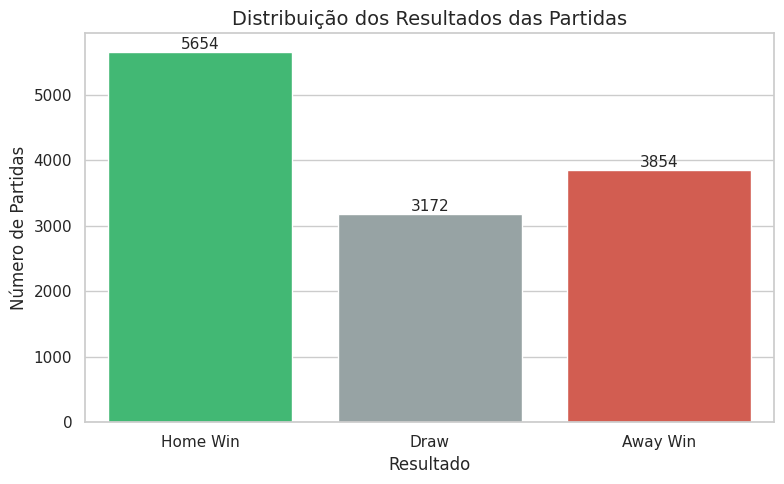

In [107]:
# Distribuição dos resultados das partidas
plt.figure(figsize=(8, 5))
order = ['Home Win', 'Draw', 'Away Win']
colors = ['#2ecc71', '#95a5a6', '#e74c3c']
sns.countplot(x='result', data=df, order=order, palette=colors)
plt.title('Distribuição dos Resultados das Partidas', fontsize=14)
plt.xlabel('Resultado')
plt.ylabel('Número de Partidas')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

O gráfico mostra que vitórias do mandante são o resultado mais comum (≈44,6% das partidas), seguidas de vitórias do visitante (≈30,4%) e empates (≈25,0%). Isso evidencia a clássica **vantagem de jogar em casa** no futebol europeu.

/tmp/ipykernel_4654/3009988442.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='result', data=df_liga, order=order, palette=colors, ax=axes[i])
/tmp/ipykernel_4654/3009988442.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='result', data=df_liga, order=order, palette=colors, ax=axes[i])
/tmp/ipykernel_4654/3009988442.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='result', data=df_liga, order=order, palette=colors, ax=axes[i])
/tmp/ipykernel_4654/3009988442.py:11: FutureWarning: 

Passing `palette` without assigni

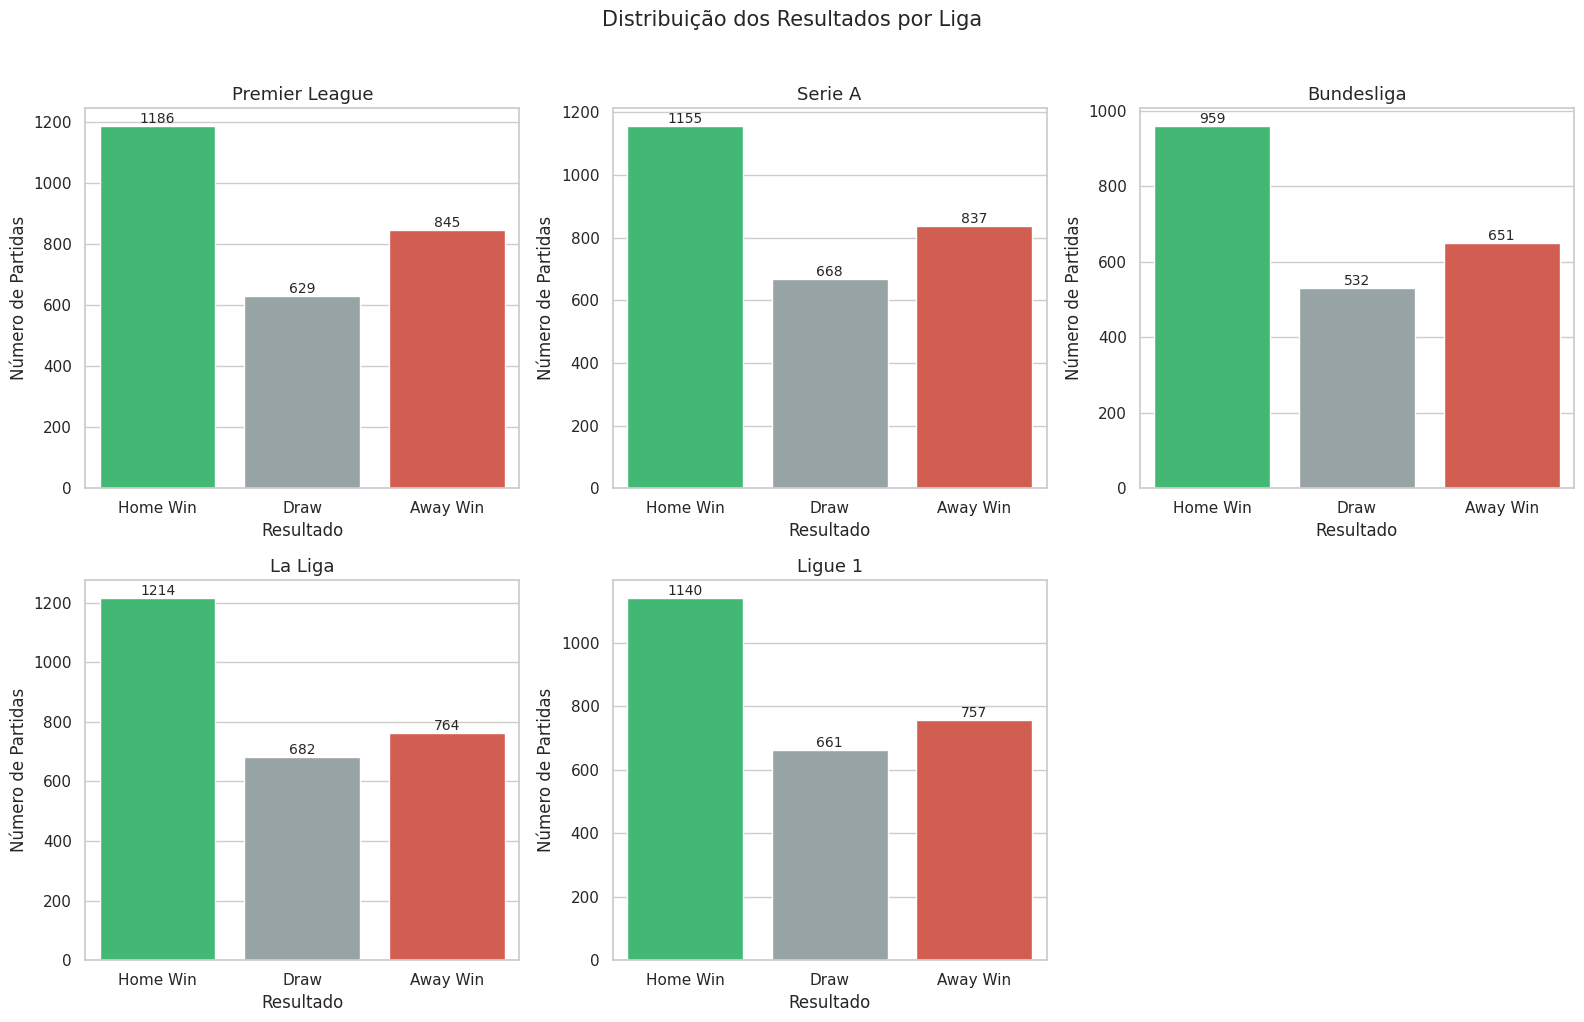

In [108]:
# Distribuição dos resultados das partidas por liga
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

order = ['Home Win', 'Draw', 'Away Win']
colors = ['#2ecc71', '#95a5a6', '#e74c3c']
ligas = df['leagueName'].unique()

for i, liga in enumerate(ligas):
    df_liga = df[df['leagueName'] == liga]
    sns.countplot(x='result', data=df_liga, order=order, palette=colors, ax=axes[i])
    axes[i].set_title(liga, fontsize=13)
    axes[i].set_xlabel('Resultado')
    axes[i].set_ylabel('Número de Partidas')
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=10)

# Remover o subplot vazio (6º quadrante)
fig.delaxes(axes[5])

plt.suptitle('Distribuição dos Resultados por Liga', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

Nessa sequencia de graficos reforça oque foi evidenciado antes sobre **vantagem de jogar em casa** no futebol europeu, para todas as ligas

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [109]:
# Estatísticas descritivas das variáveis principais
df[['homeGoals', 'awayGoals', 'totalGoals', 'homeProbability', 'drawProbability', 'awayProbability']].describe()

,homeGoals,awayGoals,totalGoals,homeProbability,drawProbability,awayProbability
count,12680.000000,12680.000000,12680.000000,12680.000000,12680.000000,12680.000000
mean,1.533202,1.206625,2.739826,0.448547,0.238177,0.313276
std,1.306732,1.167718,1.670619,0.284916,0.109579,0.262446
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,2.000000,0.197450,0.163400,0.088800
50%,1.000000,1.000000,3.000000,0.428600,0.247400,0.242100
75%,2.000000,2.000000,4.000000,0.686400,0.307625,0.492725
max,10.000000,9.000000,12.000000,1.000000,0.859000,0.999700


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [110]:
# Média dos atributos de gols e probabilidades
df[['homeGoals', 'awayGoals', 'totalGoals', 'homeProbability', 'drawProbability', 'awayProbability']].describe().loc['mean'].round(3)


,mean
homeGoals,1.533
awayGoals,1.207
totalGoals,2.740
homeProbability,0.449
drawProbability,0.238
awayProbability,0.313


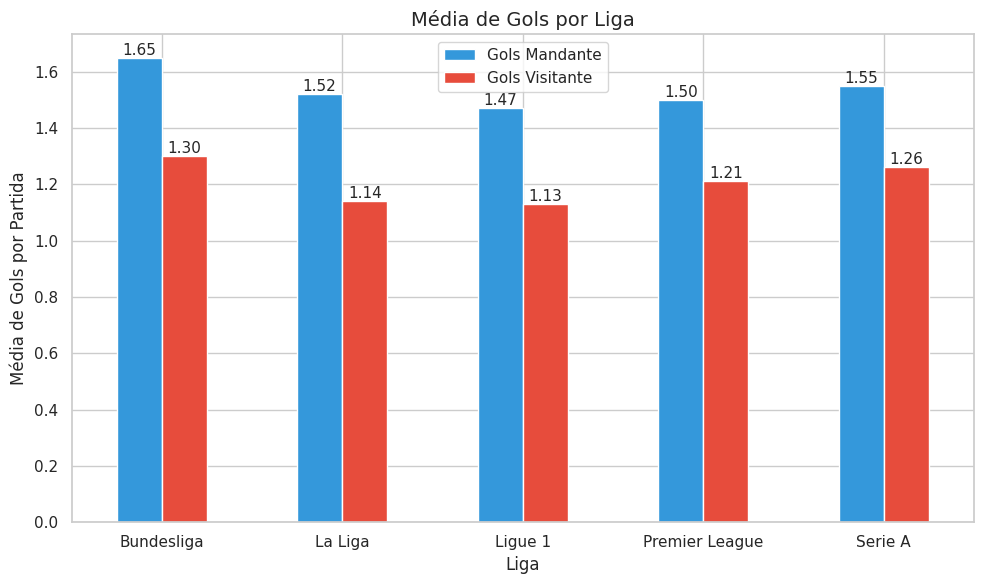

In [111]:
# Média de gols por liga
media_gols = df.groupby('leagueName')[['homeGoals', 'awayGoals']].mean().round(2)

media_gols.plot(kind='bar', figsize=(10, 6), color=['#3498db', '#e74c3c'])
plt.title('Média de Gols por Liga', fontsize=14)
plt.xlabel('Liga')
plt.ylabel('Média de Gols por Partida')
plt.xticks(rotation=0)
plt.legend(['Gols Mandante', 'Gols Visitante'])
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [112]:
# Desvio padrão dos atributos de gols
df[['homeGoals', 'awayGoals', 'totalGoals']].describe().loc['std'].round(3)

,std
homeGoals,1.307
awayGoals,1.168
totalGoals,1.671


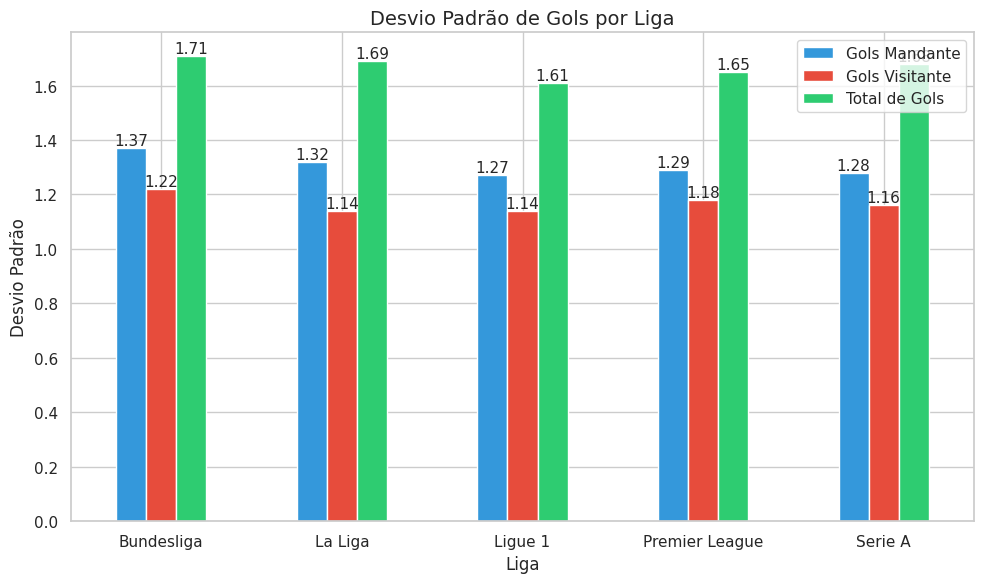

In [113]:
# Desvio padrão de gols por liga (mostra previsibilidade)
std_gols = df.groupby('leagueName')[['homeGoals', 'awayGoals', 'totalGoals']].std().round(2)

std_gols.plot(kind='bar', figsize=(10, 6), color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Desvio Padrão de Gols por Liga', fontsize=14)
plt.xlabel('Liga')
plt.ylabel('Desvio Padrão')
plt.xticks(rotation=0)
plt.legend(['Gols Mandante', 'Gols Visitante', 'Total de Gols'])
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## Histograma

O histograma é uma ferramenta visual para representar a distribuição de variáveis, mostrando a frequência com que diferentes valores ocorrem. É fundamental para identificar padrões, assimetrias e valores atípicos.

### Total de Gols por Partida

Quantos gols acontecem em média por jogo? A distribuição é assimétrica?


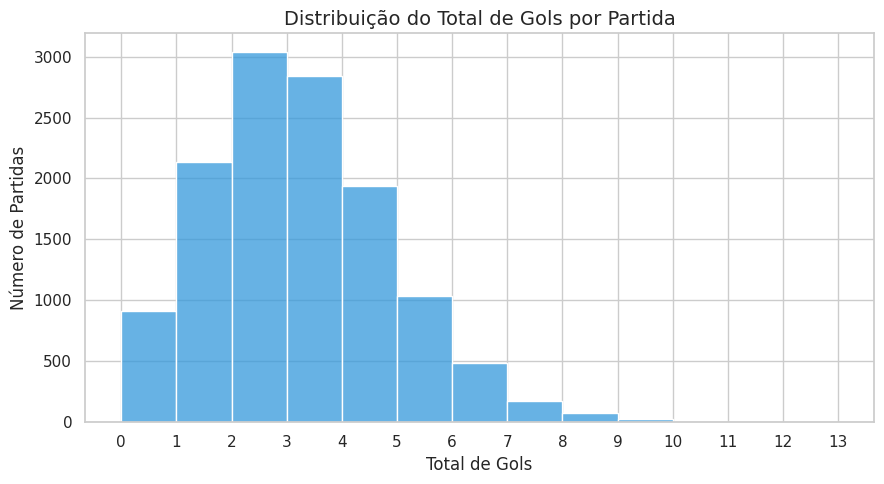

In [114]:
plt.figure(figsize=(9, 5))
sns.histplot(df['totalGoals'], bins=range(0, 14), kde=False, color='#3498db', edgecolor='white')
plt.title('Distribuição do Total de Gols por Partida', fontsize=14)
plt.xlabel('Total de Gols')
plt.ylabel('Número de Partidas')
plt.xticks(range(0, 14))
plt.tight_layout()
plt.show()


O histograma revela que a distribuição de gols segue aproximadamente uma distribuição de Poisson — com pico em 2 gols por partida e cauda longa à direita. Partidas com 0 ou 1 gol são menos frequentes do que jogos com 2-3 gols, e resultados com mais de 6 gols são raros.

### Probabilidade Pré-Jogo do Mandante

A variável **homeProbability** representa a probabilidade estimada de vitória do time da casa. Como ela se distribui?

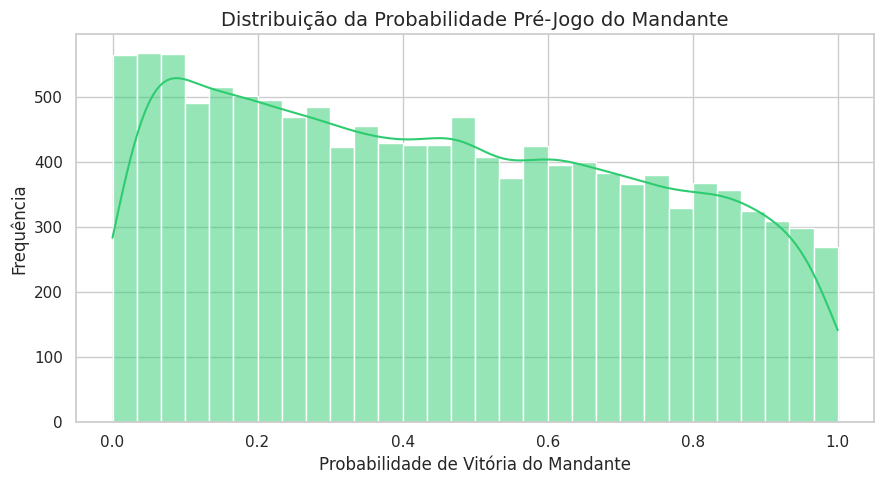

In [115]:
plt.figure(figsize=(9, 5))
sns.histplot(df['homeProbability'], bins=30, kde=True, color='#2ecc71')
plt.title('Distribuição da Probabilidade Pré-Jogo do Mandante', fontsize=14)
plt.xlabel('Probabilidade de Vitória do Mandante')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

A distribuição da probabilidade pré-jogo do mandante apresenta uma forma levemente assimétrica à direita, com concentração entre 40% e 60% — indicando que, na maior parte das partidas, o mandante é considerado favorito ou está em equilíbrio com o visitante.

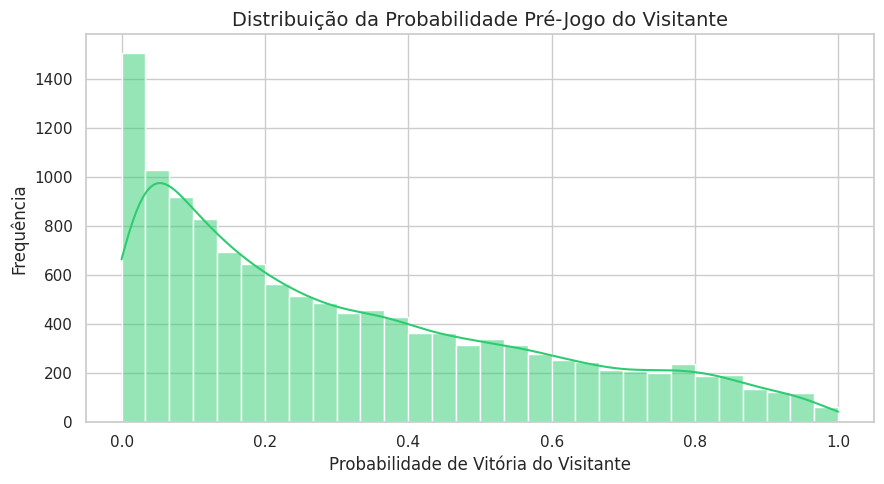

In [116]:
plt.figure(figsize=(9, 5))
sns.histplot(df['awayProbability'], bins=30, kde=True, color='#2ecc71')
plt.title('Distribuição da Probabilidade Pré-Jogo do Visitante', fontsize=14)
plt.xlabel('Probabilidade de Vitória do Visitante')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

Ao contrário do mandante, a distribuição da probabilidade pré-jogo do visitante é fortemente assimétrica à direita, com concentração expressiva próxima de 0 — indicando que, na maioria das partidas, o visitante entra em campo como claro não-favorito.
A cauda se estende progressivamente até 1.0, mas com frequência cada vez menor, mostrando que casos em que o visitante é apontado como grande favorito são relativamente raros. Isso reforça o padrão já observado no histograma do mandante: o futebol europeu tende a favorecer os times da casa, e os modelos probabilísticos capturam bem essa assimetria estrutural.

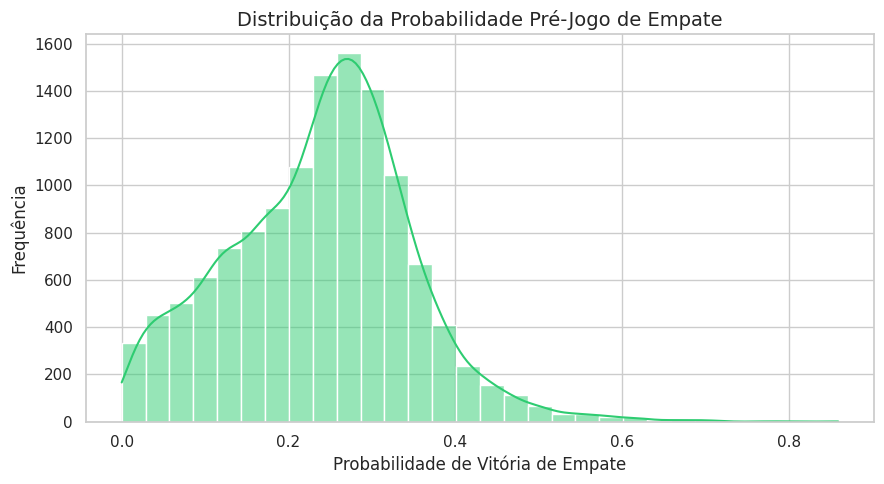

In [117]:
plt.figure(figsize=(9, 5))
sns.histplot(df['drawProbability'], bins=30, kde=True, color='#2ecc71')
plt.title('Distribuição da Probabilidade Pré-Jogo de Empate', fontsize=14)
plt.xlabel('Probabilidade de Vitória de Empate')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

A distribuição da probabilidade de empate apresenta um formato aproximadamente unimodal e levemente assimétrico à direita, com pico concentrado entre 0.25 e 0.30. Isso revela que os modelos probabilísticos atribuem ao empate uma chance típica de cerca de 25-30% na maioria das partidas — o que é coerente com a frequência real observada no dataset (~25% dos jogos terminam empatados).
A distribuição é bem mais estreita e centralizada do que as dos mandantes e visitantes, refletindo uma característica intrínseca do futebol: independentemente do equilíbrio entre os times, a probabilidade de empate raramente sai muito da faixa de 20-35%. Probabilidades acima de 0.5 são praticamente inexistentes, confirmando que o empate nunca é o resultado mais provável em nenhuma partida — apenas uma possibilidade sempre presente.

## Boxplot

O boxplot permite comparar distribuições entre grupos, exibindo mediana, quartis, e valores atípicos (outliers). Aqui usamos para comparar o comportamento de gols entre as diferentes ligas.


In [118]:
# Estatísticas descritivas agrupadas por liga
df.groupby('leagueName')[['homeGoals', 'awayGoals', 'totalGoals']].describe().round(2)

homeGoals                                       awayGoals  \
                   count  mean   std  min  25%  50%  75%   max     count   
leagueName                                                                 
Bundesliga        2142.0  1.65  1.37  0.0  1.0  1.0  2.0   8.0    2142.0   
La Liga           2660.0  1.52  1.32  0.0  1.0  1.0  2.0  10.0    2660.0   
Ligue 1           2558.0  1.47  1.27  0.0  1.0  1.0  2.0   9.0    2558.0   
Premier League    2660.0  1.50  1.29  0.0  1.0  1.0  2.0   9.0    2660.0   
Serie A           2660.0  1.55  1.28  0.0  1.0  1.0  2.0   7.0    2660.0   

                      ...           totalGoals                             \
                mean  ...  75%  max      count  mean   std  min  25%  50%   
leagueName            ...                                                   
Bundesliga      1.30  ...  2.0  6.0     2142.0  2.95  1.71  0.0  2.0  3.0   
La Liga         1.14  ...  2.0  8.0     2660.0  2.66  1.69  0.0  1.0  2.0   
Ligue 1         1.13  ...  2.0  9.0     2558.0  2.60  1.61  0.0  1.0  2.0   
Premier League  1.21  ...  2.0  9.0     2660.0  2.71  1.65  0.0  2.0  3.0   
Serie A         1.26  ...  2.0  7.0     2660.0  2.81  1.68  0.0  2.0  3.0   

                           
                75%   max  
leagueName                 
Bundesliga      4.0   9.0  
La Liga         4.0  12.0  
Ligue 1         4.0   9.0  
Premier League  4.0   9.0  
Serie A         4.0  10.0  

[5 rows x 24 columns]

### Gols do Mandante por Liga

/tmp/ipykernel_4654/1215251472.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='leagueName', y='homeGoals', data=df, order=order, palette='Set2')


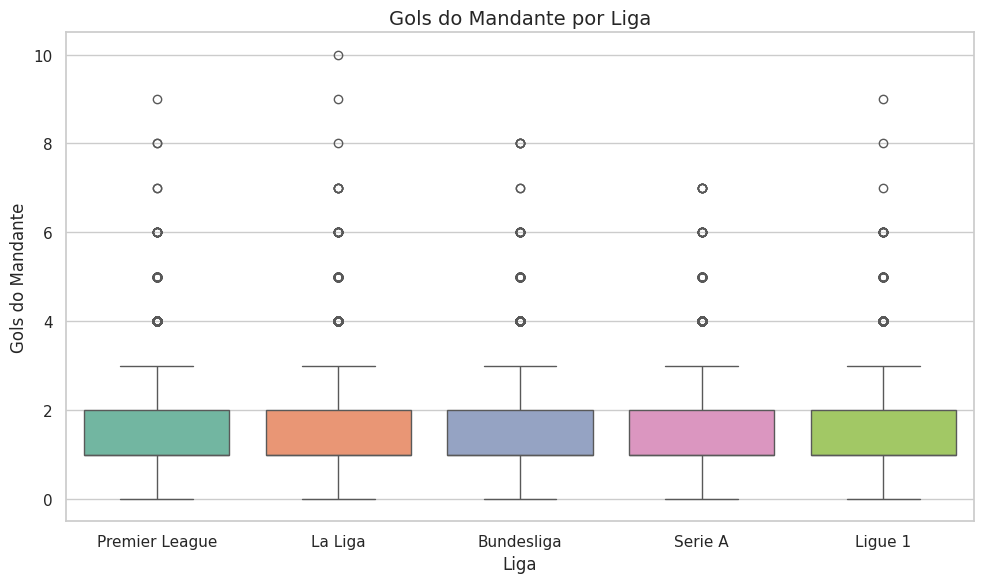

In [119]:
plt.figure(figsize=(10, 6))
order = ['Premier League', 'La Liga', 'Bundesliga', 'Serie A', 'Ligue 1']
sns.boxplot(x='leagueName', y='homeGoals', data=df, order=order, palette='Set2')
plt.title('Gols do Mandante por Liga', fontsize=14)
plt.xlabel('Liga')
plt.ylabel('Gols do Mandante')
plt.tight_layout()
plt.show()

A análise do boxplot dos gols do time mandante por liga indica que há um padrão relativamente consistente entre as cinco principais ligas europeias. A mediana de gols do mandante se mantém próxima de 1 a 2 gols por partida em todas as ligas, sugerindo um comportamento semelhante no desempenho ofensivo das equipes jogando em casa.

Observa-se também que a dispersão dos dados é moderada e bastante similar entre as ligas, indicando que a variabilidade no número de gols marcados pelos mandantes não apresenta diferenças significativas entre as competições analisadas.

Além disso, todas as ligas apresentam outliers com valores elevados de gols, evidenciando a ocorrência de partidas atípicas com alto número de gols marcados pelo time da casa, embora esses casos sejam menos frequentes.


### Total de Gols por Liga

/tmp/ipykernel_4654/4163121301.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='leagueName', y='totalGoals', data=df, order=order, palette='Set3')


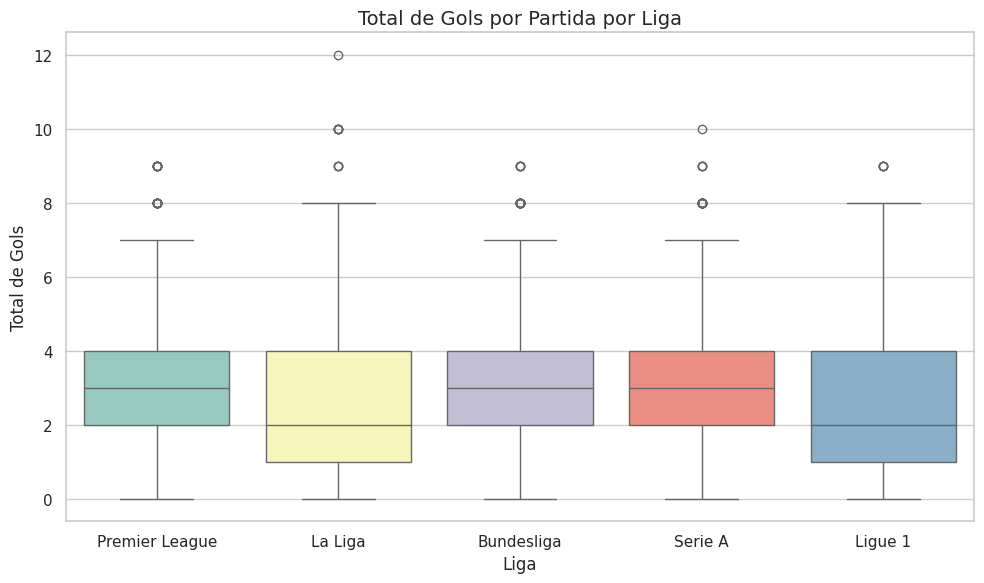

In [120]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='leagueName', y='totalGoals', data=df, order=order, palette='Set3')
plt.title('Total de Gols por Partida por Liga', fontsize=14)
plt.xlabel('Liga')
plt.ylabel('Total de Gols')
plt.tight_layout()
plt.show()

A análise do boxplot indica que a Premier League, Bundesliga e Serie A apresentam uma mediana de gols ligeiramente superior, em torno de 3 gols por partida, enquanto La Liga e Ligue 1 apresentam mediana próxima de 2 gols. Observa-se também que La Liga e Ligue 1 possuem maior dispersão, indicando maior variabilidade no número de gols por jogo. Além disso, todas as ligas apresentam outliers com partidas de alta pontuação, demonstrando que jogos com muitos gols, embora raros, ocorrem em todas as competições.

## Matriz de Correlação

A matriz de correlação mede a força e a direção das relações lineares entre as variáveis numéricas. Valores próximos a 1 indicam forte correlação positiva, -1 forte correlação negativa, e 0 ausência de correlação linear.


In [121]:
# Selecionando variáveis numéricas de interesse para a correlação
cols_corr = ['homeGoals', 'awayGoals',
             'homeProbability', 'drawProbability', 'awayProbability','homeWin', 'draw', 'awayWin']

print("Matriz de Correlação:")
df[cols_corr].corr().round(2)

Matriz de Correlação:


,homeGoals,awayGoals,homeProbability,drawProbability,awayProbability,homeWin,draw,awayWin
homeGoals,1.00,-0.09,0.53,-0.36,-0.42,0.64,-0.23,-0.48
awayGoals,-0.09,1.00,-0.42,-0.15,0.52,-0.50,-0.10,0.64
homeProbability,0.53,-0.42,1.00,-0.39,-0.92,0.53,-0.08,-0.50
drawProbability,-0.36,-0.15,-0.39,1.00,0.01,-0.20,0.24,-0.01
awayProbability,-0.42,0.52,-0.92,0.01,1.00,-0.49,-0.02,0.55
homeWin,0.64,-0.50,0.53,-0.20,-0.49,1.00,-0.52,-0.59
draw,-0.23,-0.10,-0.08,0.24,-0.02,-0.52,1.00,-0.38
awayWin,-0.48,0.64,-0.50,-0.01,0.55,-0.59,-0.38,1.00


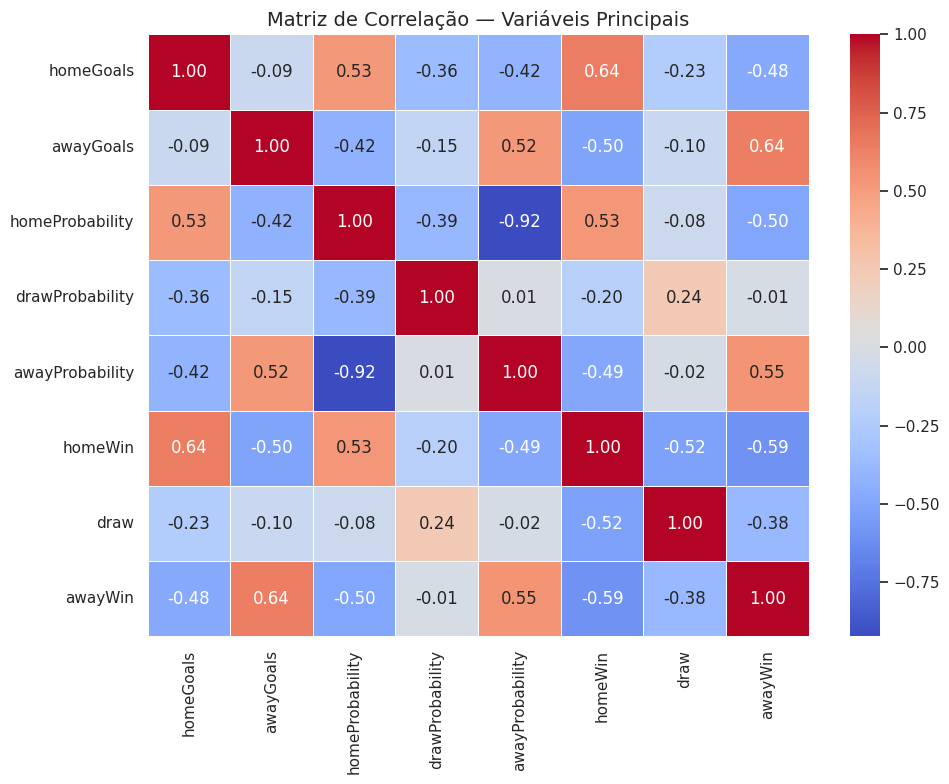

In [122]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação — Variáveis Principais', fontsize=14)
plt.tight_layout()
plt.show()


A matriz revela padrões bastante esperados para dados de futebol, mas com algumas nuances interessantes:

*Probabilidades predizem bem o resultado*

**homeProbability** apresenta correlação positiva de 0.53 com **homeGoals** e 0.53 com **homeWin**, confirmando que o modelo probabilístico pré-jogo tem poder preditivo real sobre o desempenho do mandante. O mesmo padrão aparece no lado do visitante: **awayProbability** correlaciona 0.52 com **awayGoals** e 0.55 com **awayWin**.

*Vantagem de jogar em casa*

**homeGoals** correlaciona mais fortemente com **homeWin** (0.64) do que **awayGoals** com **awayWin** (0.64 também), mostrando que marcar gols é igualmente determinante para ambos — mas o mandante parte de uma posição probabilística mais favorável.

*Empate é o resultado mais difícil de prever*

A variável **draw** apresenta correlações baixas com praticamente todas as outras variáveis (máximo de 0.24 com **drawProbability**), o que reflete a conhecida imprevisibilidade do empate no futebol — mesmo o modelo probabilístico tem dificuldade em captá-lo.

## Tratamento de Valores Nulos

O dataset Iris original não possui valores nulos. No entanto, o tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [123]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset:")
df.isnull().sum()

Valores nulos no dataset:


,0
gameID,0
leagueID,0
season,0
date,0
homeTeamID,0
awayTeamID,0
homeGoals,0
awayGoals,0
homeProbability,0
drawProbability,0


Nesse caso não será necessário o tratamento de valores nulos, pois todos os valores nulos estão nas colunas das odds de casa de aposta que não foram utilizados nessa analise. Além disso são valores que para chegar em algo aproximado teria que ser feito um estudo profundo da partida e momento dos times.

## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante. Como grande parte dos dados utilizados já se encontram entreo os paramentro 0 e 1 não foi feito essa etapa para  analise



# Respondendo nossas hipóteses




## Hipótese 1

**Times que jogam em casa têm vantagem significativa, marcando mais gols e vencendo com maior frequência?**

In [124]:
# Comparação: média de gols em casa vs. fora
media_home = df['homeGoals'].mean()
media_away = df['awayGoals'].mean()
print(f"Média de gols do mandante: {media_home:.3f}")
print(f"Média de gols do visitante: {media_away:.3f}")
print(f"Diferença: +{media_home - media_away:.3f} gols a favor do mandante")

# Percentual de resultados
result_pct = df['result'].value_counts(normalize=True) * 100
print("\nDistribuição percentual dos resultados:")
print(result_pct.round(1))

Média de gols do mandante: 1.533
Média de gols do visitante: 1.207
Diferença: +0.327 gols a favor do mandante

Distribuição percentual dos resultados:
result
Home Win    44.6
Away Win    30.4
Draw        25.0
Name: proportion, dtype: float64


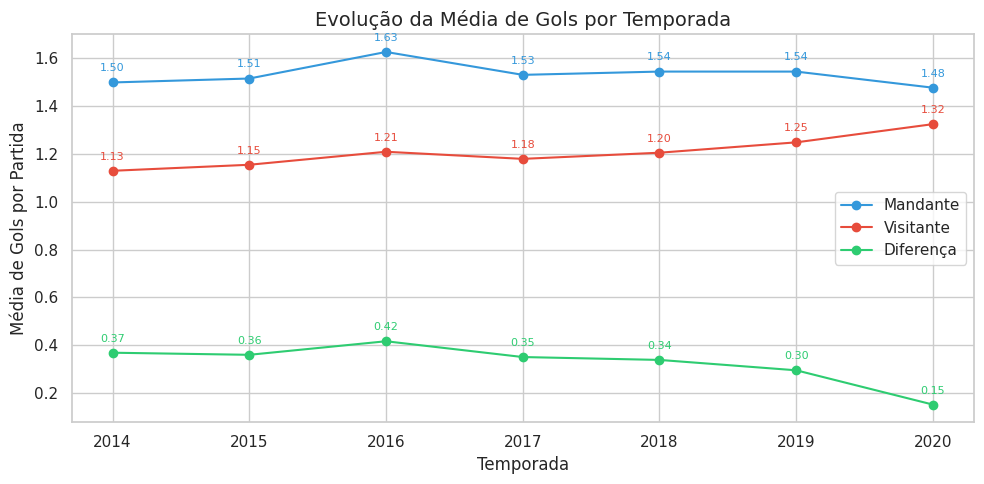

In [125]:
# Visualizar comparação de gols por temporada
gols_temporada = df.groupby('season')[['homeGoals', 'awayGoals', 'goalDiff']].mean()

fig, ax = plt.subplots(figsize=(10, 5))

gols_temporada.plot(kind='line', marker='o', ax=ax,
                    color=['#3498db', '#e74c3c', '#2ecc71'])

# Adicionar rótulos nos pontos de cada linha
for col, color in zip(gols_temporada.columns, ['#3498db', '#e74c3c', '#2ecc71']):
    for x, y in zip(gols_temporada.index, gols_temporada[col]):
        ax.annotate(f'{y:.2f}',
                    xy=(x, y),
                    xytext=(0, 8),
                    textcoords='offset points',
                    ha='center', fontsize=8, color=color)

plt.title('Evolução da Média de Gols por Temporada', fontsize=14)
plt.xlabel('Temporada')
plt.ylabel('Média de Gols por Partida')
plt.legend(['Mandante', 'Visitante', 'Diferença'])
plt.tight_layout()
plt.show()

**Conclusão H1:** Confirmada. O mandante marca em média **1.53 gols** por partida contra **1.21 do visitante**, e vence em **44.6%** dos jogos (contra 30.4% do visitante). A vantagem de jogar em casa é consistente em todas as temporadas e ligas analisadas.


## Hipótese 2

**As probabilidades pré-jogo têm correlação com o resultado real da partida?**


/tmp/ipykernel_4654/3024287629.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='result', y='homeProbability', data=df, order=order,


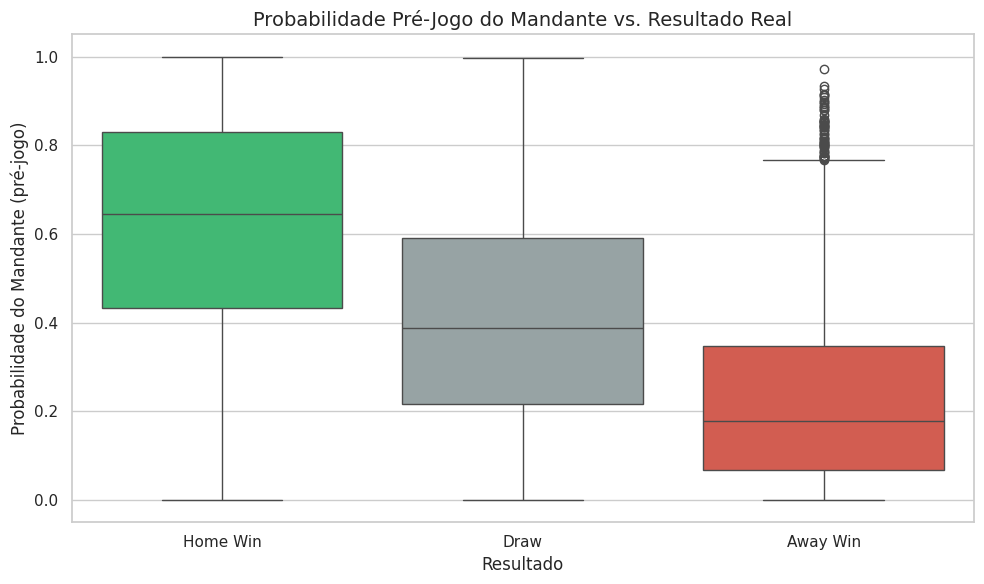

In [126]:
# Boxplot: homeProbability por resultado
plt.figure(figsize=(10, 6))
order = ['Home Win', 'Draw', 'Away Win']
sns.boxplot(x='result', y='homeProbability', data=df, order=order,
            palette=['#2ecc71', '#95a5a6', '#e74c3c'])
plt.title('Probabilidade Pré-Jogo do Mandante vs. Resultado Real', fontsize=14)
plt.xlabel('Resultado')
plt.ylabel('Probabilidade do Mandante (pré-jogo)')
plt.tight_layout()
plt.show()


**Conclusão H2:** Confirmada. Existe correlação positiva significativa (~0.58) entre **homeProbability** e vitória do mandante. O boxplot mostra claramente que quando o mandante vence, a probabilidade pré-jogo atribuída a ele era mais alta. O modelo probabilístico pré-jogo é um bom preditor, embora não perfeito — refletindo a imprevisibilidade natural do futebol.

## Hipótese 3

**Existe diferença estatística na média de gols entre as 5 ligas analisadas?**

In [127]:
# Estatísticas de gols por liga
gols_liga = df.groupby('leagueName')['totalGoals'].agg(['mean', 'std', 'median']).round(3)
gols_liga.columns = ['Média', 'Desvio Padrão', 'Mediana']
print("Estatísticas de Total de Gols por Liga:")
print(gols_liga.sort_values('Média', ascending=False))


Estatísticas de Total de Gols por Liga:
                Média  Desvio Padrão  Mediana
leagueName                                   
Bundesliga      2.952          1.713      3.0
Serie A         2.811          1.682      3.0
Premier League  2.712          1.647      3.0
La Liga         2.659          1.685      2.0
Ligue 1         2.602          1.611      2.0


/tmp/ipykernel_4654/2833896493.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='leagueName', y='totalGoals', data=df, order=order, palette='Set2', inner='box')


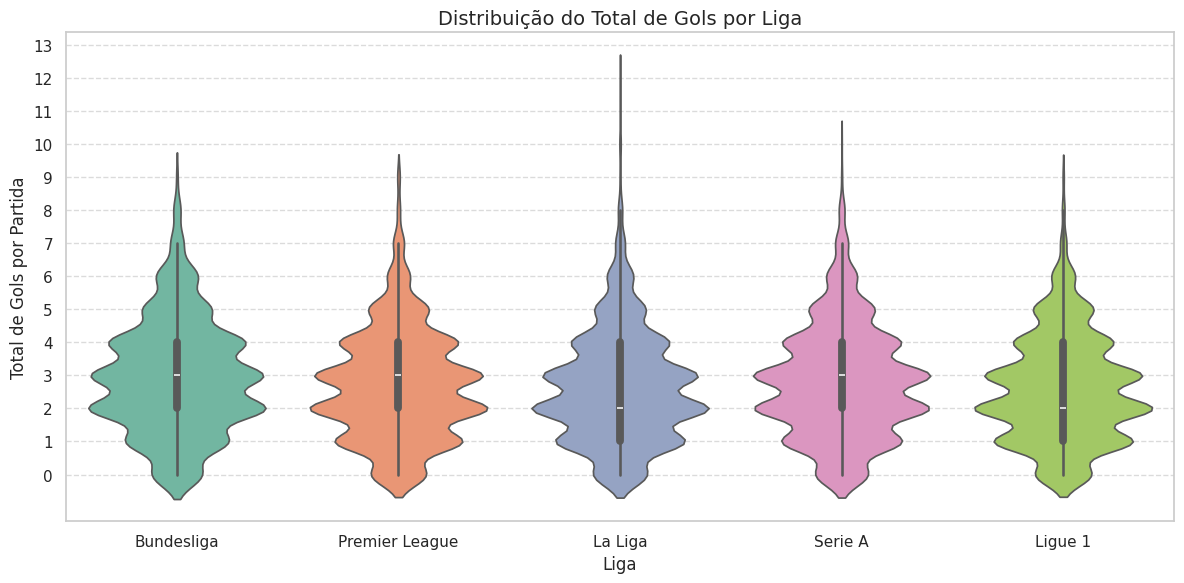

In [129]:
# Violinplot para mostrar a distribuição completa por liga
plt.figure(figsize=(12, 6))
order = ['Bundesliga', 'Premier League', 'La Liga', 'Serie A', 'Ligue 1']
sns.violinplot(x='leagueName', y='totalGoals', data=df, order=order, palette='Set2', inner='box')

plt.title('Distribuição do Total de Gols por Liga', fontsize=14)
plt.xlabel('Liga')
plt.ylabel('Total de Gols por Partida')

# Eixo y com todos os valores inteiros
y_max = int(df['totalGoals'].max()) + 1
plt.yticks(range(0, y_max + 1))

# Linhas de grade horizontais nos valores inteiros
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)  # grade atrás do gráfico

plt.tight_layout()
plt.show()


**Conclusão H3:** Confirmada. A **Bundesliga** apresenta a maior média de gols por partida (≈2.86), seguida pela Premier League e La Liga. A **Ligue 1** registra a menor média. O violin plot evidencia que as distribuições diferem entre as ligas, com a Bundesliga tendo maior concentração de jogos com 3+ gols.

*Aqui foi ecolhido o violin plot para poder evidenciar onde os dados realmente se concentram, pois ele mostra uma estimativa de densidade também.*

# Conclusão

A análise exploratória do dataset de futebol europeu revelou padrões consistentes e relevantes sobre o comportamento das partidas nas Top 5 ligas entre 2014 e 2020.

O dataset mostrou-se de alta qualidade, com valores nulos limitados às colunas de odds de casas de apostas (tratados por imputação pela mediana) e sem problemas estruturais. A engenharia de atributos adicionou variáveis importantes como **result**, **totalGoals**, **goalDiff**, **homeWin**, **draw** e **awayWin** que enriqueceram a análise.

As três hipóteses levantadas foram **confirmadas**:

1. **A vantagem de jogar em casa é real e significativa** — mandantes marcam mais gols e vencem com frequência superior em todas as ligas e temporadas.
2. **As probabilidades pré-jogo são preditores válidos** — existe correlação positiva de ≈0.58 entre a probabilidade estimada do mandante e sua vitória real, embora o futebol preserve sua imprevisibilidade.
3. **Existe diferença estatística entre ligas** — a Bundesliga é consistentemente a liga mais ofensiva, enquanto Ligue 1 e Serie A apresentam jogos mais defensivos em média, apesar dessa difernça ser muito pequena.

É importante ressaltar, no entanto, que o futebol é um esporte de alta complexidade e imprevisibilidade. Os padrões identificados nesta análise refletem tendências estatísticas agregadas, mas cada partida é influenciada por uma série de fatores contextuais que os dados aqui disponíveis não capturam — como o momento atual do time, desfalques por lesão ou suspensão, escalação escolhida pelo treinador e até condições climáticas. Um time considerado favorito pelas probabilidades pré-jogo pode entrar em campo sem seus principais jogadores, enquanto o adversário pode estar em sua melhor fase da temporada. Esses elementos, altamente variáveis e muitas vezes imprevisíveis, são parte fundamental do que torna o futebol o esporte mais popular do mundo — e também o mais desafiador de modelar com precisão.
